#Assignment 3: Clustering

In this assignment, you will:


*   Use ```Pandas``` to load and inspect data
*   Use tools from ```sklearn``` to pre-process data for training and testing
*   Code your own implementation of K-means and K-means++
*   Use tools from ```sklearn``` to train multiple clustering algorithms and optimize performance
*   Compare the performance of these algorithms
*   Add text cells with writeup with your answers (indicated throughout the assignment)

**If you used AI to complete this assignment, edit this text box to include the tool used.**

I used the following AI tool to complete this assignment (leave blank if none):

Additional questions: were there any mistakes that the AI made that you had to correct? If so, list one example.

#Part 1: Load, Pre-process, and Inspect Data

For Part 1 of this assignment, we will use a [dataset of Starbucks Customer Data](https://www.kaggle.com/datasets/ihormuliar/starbucks-customer-data?select=profile.csv), specifically the ```profile.csv``` dataset. This dataset contains data on customers with Starbucks app accounts, including their ages, incomes, and dates they joined the app.

A note: this assignment has less guiding information on purpose. Now that you have had practice working with datasets and sklearn, many of these steps will feel familiar. You will be implementing an algorithm (k-means) in this homework; the pseudocode for implementation can be found in the course slides and readings. However, if you are stuck while implementing this without more guidance, let us know on Ed or in office hours!


1. (22 pts total) **Loading, preparing, and visualizing data**

1(a) (6 pts)  First, load in the data (```profile.csv```) to a variable called ```X```. Prepare the data by:



1.  Select features: for this assignment, we'll analyze the features ```age```, ```income```, and ```became_member_on```. Filter the dataset to only contain these features.
2. Drop any rows with NaN values.
3. Convert the dates (currently in format year/month/day, so January 3 2005 is 20050103) to hours since 1970-01-01. We'll do this for you, but note the pandas functions used. This process makes the dates into a continuous variable.
3. Display the first 5 lines of data to see the dataset.

### Load

In [1]:
import pandas as pd

accounts = pd.read_csv("profile.csv")
print(accounts.columns)

Index(['Unnamed: 0', 'gender', 'age', 'id', 'became_member_on', 'income'], dtype='object')


### Select Features

In [2]:
features = ['age', 'became_member_on', 'income']
X = accounts[features]
X.head()

,age,became_member_on,income
0,118,20170212,NaN
1,55,20170715,112000.0
2,118,20180712,NaN
3,75,20170509,100000.0
4,118,20170804,NaN


### Clean Dataset

In [3]:
X_cleaned = X.dropna().copy()

print(f'Total rows before clean: {len(X)}')
print(f'Total rows after clean: {len(X_cleaned)}')
print(f'Rows with missing data: {len(X) - len(X_cleaned)}')


Total rows before clean: 17000
Total rows after clean: 14825
Rows with missing data: 2175


### Transform Features

In [4]:
# Convert to days since 1970-01-01
X_cleaned['became_member_on'] = pd.to_datetime(X_cleaned['became_member_on'].astype(str), format='%Y%m%d')
X_cleaned['became_member_on'] = (X_cleaned['became_member_on'] - pd.Timestamp('1970-01-01')).dt.days

### Display

In [5]:
X_cleaned.head()

,age,became_member_on,income
1,55,17362,112000.0
3,75,17295,100000.0
5,68,17647,70000.0
8,65,17571,53000.0
12,58,17481,51000.0


Finally, standardize the data for clustering algorithms. Keep the original data as well; we will use it to analyze clusters.

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_std = scaler.fit_transform(X_cleaned)

1(b) (10 pts). We'll use [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) from sklearn to visualize the data in 2D. Use PCA and its [```fit_transform```](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.fit_transform) method to convert features, and save the result in a variable called **X_pca**. Compute all three (3) PCA features.

**Without using the  ```explained_variance_ratio_``` attribute of PCA**,  calculate the percentage of variance explained by each of the selected components. You can use the ```explained_variance_``` attribute of PCA, which contains the eigenvalues of each component. Using this information, find the total percentage of variance explained by the **first two** PCA-created features.

In [7]:
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA to retain 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_std)

### Explained Variance Ratio

In [8]:
# Manually calculate explained variance ratio for all components
# TODO

print(np.round(pca.explained_variance_ / X_std.var(axis=0, ddof=1).sum(), 2))

[0.44 0.33 0.23]


### Variance explained by the first two PCA-created features

In [9]:
# Manually calculate variance explained by the first two PCA-created features

# TODO

print(np.round(pca.explained_variance_[:2].sum() / X_std.var(axis=0, ddof=1).sum(), 2))

0.77


**Question:** What is the explained variance ratio for components 1, 2, and 3, each rounded to two decimal places?

**Answer:** The explained variance ratio for components 1, 2, and 3 is 0.44, 0.33 and 0.23 respectively.

**Question:** What is the total explained variance of the first two PCA-created features, rounded to two decimal places?

**Answer**: The percentage of total explain variance is 0.77.

Next, we'll plot the **first two (2)** features obtained using PCA using a [matplotlib scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) for you. In this plot, the PCA data is colored by the features of the original data to help visualize the correlations between the learn and original features.

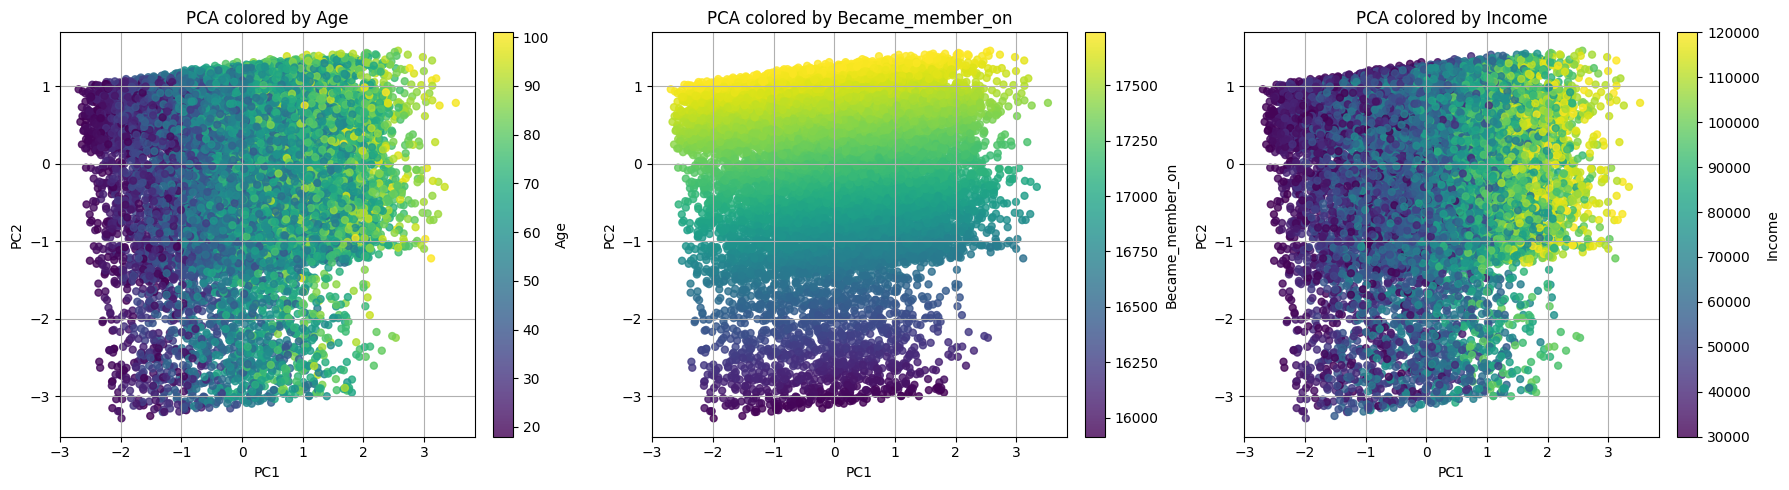

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import the 3D plotting toolkit

fig, axes = plt.subplots(1, len(features), figsize=(18, 5))

for ax, attr in zip(axes, features):
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=X_cleaned[attr].to_numpy(),
        s=25,
        alpha=0.8,
        cmap="viridis"
    )
    ax.set_title(f"PCA colored by {attr.capitalize()}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(attr.capitalize())

plt.tight_layout()
plt.show()

1(c) (6 pts). The absolute values of the ```components_``` attribute of sklearn's PCA represent the magnitude of the correlation between the original features ('age', 'became_member_on', 'income') and the principal components. Find these absolute values for each feature with regards to the first and second PCA feature.

In [12]:
# Find absolute value of pca.components_

# TODO
print(np.abs(pca.components_[:2]))

[[0.70348694 0.08681538 0.70538586]
 [0.08339763 0.99573805 0.03937736]]


**Question:** What feature(s) contribute(s) most highly to the first PCA feature?

**Answer:** The feature 'income' contributes the most to the first PCA feature

**Question:** What feature(s) contribute(s) most highly to the second PCA feature?

**Answer:** The feature 'became_member_on' contributes the most to the second PCA feature as well.

2. (34 pts total) **Implementing and testing K-means**

In this question, you will implement and run the k-means algorithm on the **3d scaled** data, and visualize the clusters on the **2d PCA** data as well as on the **3d unscaled** data.

2(a) (25 pts). Using Euclidean distance as your distance metric, implement the k-means algorithm as described in class. So that we can compare answers easily, implement the naive sharding initialization algorithm to avoid randomness in k-means centroid initialization. Use the first dimension to sort the data.

For convergence, check that the centroids have stopped moving (using [```np.allclose(centroids, new_centroids```](https://numpy.org/devdocs/reference/generated/numpy.allclose.html) with the default arguments/tolerance). If the centroids have not stopped moving after 100 iterations, stop. That is, convergence is when centroids have stopped moving or 100 iterations, whichever happens first.

Where possible, vectorize your code (that is, use matrix math/operations instead of loops).

In [13]:
import numpy as np

def kmeans_clustering(X, n_clusters, max_iter=100):
    """
    K-means clustering with naive sharding initialization and a flexible distance metric.

    Args:
        X (np.ndarray): The input data as a NumPy array.
        n_clusters (int): The number of clusters.
        max_iter (int): The maximum number of iterations.
        metric (str): The distance metric to use. See scipy.spatial.distance.cdist for options.

    Returns:
        tuple: A tuple containing:
            - centroids (np.ndarray): The final centroids.
            - labels (np.ndarray): The cluster labels for each data point in the same order as the dataset.
    """

    # Initialize centroids using naive sharding
    X = np.asarray(X)

    composite = X.sum(axis=1)
    order = np.argsort(composite)
    X_sorted = X[order]
    shards = np.array_split(X_sorted, n_clusters)
    centroids = np.stack([shard.mean(axis=0) for shard in shards])

    # TODO

    # K-means loop (this loop is necessary to count iterations)
    for _ in range(max_iter):
        # calculate pairwise differences for every point and every centroid
        # https://numpy.org/doc/stable/user/basics.broadcasting.html#a-practical-example-vector-quantization
        diffs = X[:, None, :] - centroids[None, :, :]
        distances = np.sum(diffs ** 2, axis=2)

        # assign the closest centroid
        labels = np.argmin(distances, axis=1)

        # calculate centrois
        new_centroids = np.zeros_like(centroids)
        for j in range(n_clusters):
            mask = labels == j
            if np.any(mask):
                new_centroids[j] = X[mask].mean(axis=0)
            else:
                # just in case a cluster has no points yet
                new_centroids[j] = centroids[j]

        if np.allclose(centroids, new_centroids):
            centroids = new_centroids
            break

        centroids = new_centroids

    return centroids, labels

2(b) (5 pts). Use the Within-Cluster Sum of Squares (WSS) to choose a value of k for the k-means algorithm. To do so, run your k-means algorithm on your **scaled** data (not the PCA data) with 2 through 9 clusters, computing the WSS for every k. Plot the WSS for each k using [matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Visually find the "elbow" of the graph, and use that for your number of clusters. Note: we located the elbow at WSS between 17500 and 20000.

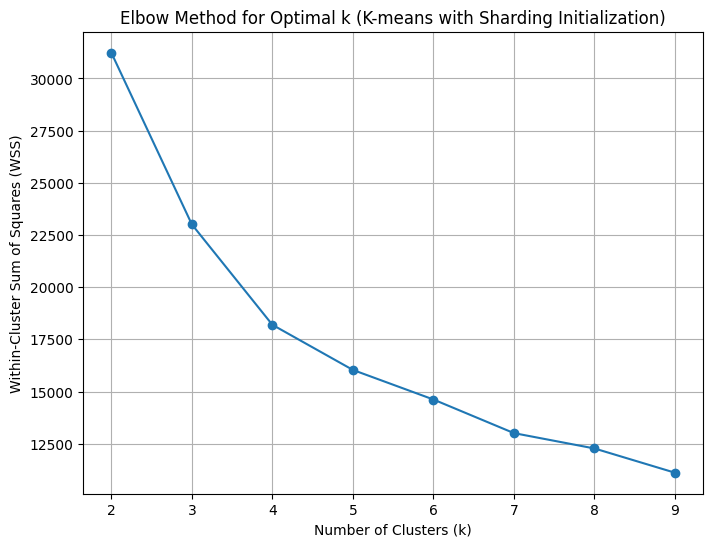

In [14]:
# Initialize empty vector to store all WSS values
wss = []
k_values = range(2, 10)  # From 2 to 9 clusters

# Calculate WSS for each selected k
for k in k_values:
    centroids, labels = kmeans_clustering(X_std, n_clusters=k, max_iter=100)

    diffs = X_std - centroids[labels]
    sq_dists = np.sum(diffs ** 2, axis=1)
    wss_k = np.sum(sq_dists)

    wss.append(wss_k)

# Plot the WSS for each k
plt.figure(figsize=(8, 6))
plt.plot(k_values, wss, marker='o')
plt.title('Elbow Method for Optimal k (K-means with Sharding Initialization)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

**Question:** What number of clusters do you choose?

**Answer:** 4

2(c) (4 pts). Find the labels using your k-means algorithm and save them in a variable named ``kmeans_labels``, using your chosen number of clusters on the **scaled** data.

Then, using a matplotlib scatter plot as shown above, we'll replot your **2D PCA** data and color code the dots by their cluster labels.

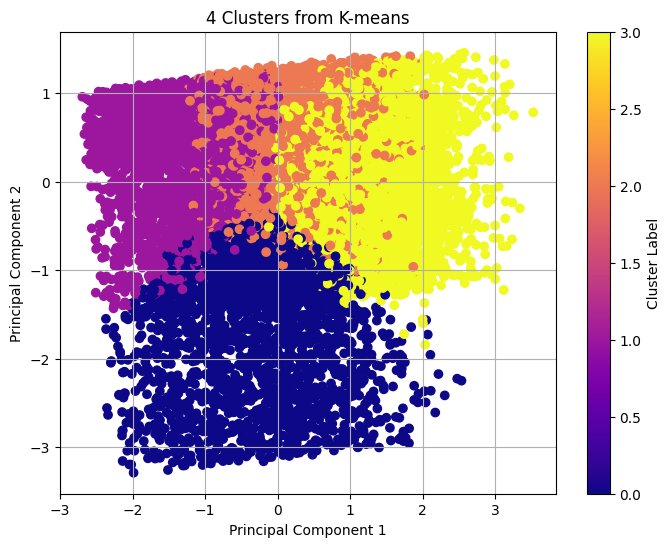

In [15]:
# Apply K-means on scaled data with selected number of clusters
n_clusters = 4 # TODO
centroids, kmeans_labels = kmeans_clustering(X_std, n_clusters=n_clusters, max_iter=100) # TODO

# Visualize the clusters

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='plasma')
plt.title(f'{n_clusters} Clusters from K-means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

We'll also show you a 3d plot of the original, unscaled data with cluster labels. We use the plotly library for this plot instead of matplotlib or seaborn, because google colab allows interactive viewing of plotly plots. You can click and drag as well as zoom on the graph image to explore the data.

In [17]:
import plotly.express as px

# Create a DataFrame for Plotly, including the cluster labels
plot_df = X_cleaned[features].copy()
plot_df['Cluster'] = kmeans_labels # Add the cluster labels

# Create the 3D scatter plot using Plotly Express
fig = px.scatter_3d(plot_df,
                    x='age',
                    y='became_member_on',
                    z='income',
                    color='Cluster', # Color by the cluster labels
                    title='3D K-means Clusters on Original Data (Plotly)')

# Update layout for better readability
fig.update_layout(scene = dict(
                    xaxis_title='Age',
                    yaxis_title='Became Member On',
                    zaxis_title='Income'),
                    margin=dict(l=0, r=0, b=0, t=40))


fig.show()

3. (9 pts total) **Gaussian Mixture Models**

Next, use sklearn's [```GaussianMixture```](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) model to find clusters in the **scaled** data. For this assignment, the only arguments to the ```GaussianMixture``` model you'll use are ```n_components``` and ```random_state=42```.

3(a) (5 pts). To find the number of components (clusters), you'll implement a similar process as you did for k-means. Try settings from 2 to 9 components, and plot the BIC (Bayes Information Criterion) to find the "elbow". You do not have to compute the BIC; the method ```GaussianMixture.bic(X)``` can do that for you. We chose an elbow with a BIC between 120000 and 120500.

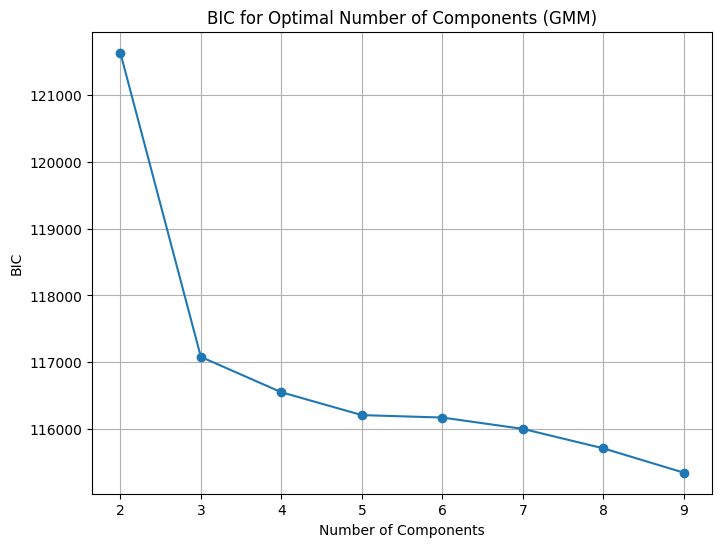

In [18]:
from sklearn.mixture import GaussianMixture

# Initialize empty vector to store all BIC values
bic = []
n_components_range = range(2, 10) # Try from 2 to 9 components


# Calculate BIC for different numbers of components using GMM
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)

    gmm.fit(X_std)

    bic_value = gmm.bic(X_std)
    bic.append(bic_value)


# Plot the BIC for each number of components
plt.figure(figsize=(8, 6))
plt.plot(n_components_range, bic, marker='o')
plt.title('BIC for Optimal Number of Components (GMM)')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.xticks(n_components_range)
plt.grid(True)
plt.show()

**Question:** What number of components do you choose based on this plot?

**Answer:** 3 However I did not identify the elbow within the same range.

3(c) (4 pts). As you did with the k-means algorithm, find the labels using the ```GaussianMixture``` algorithm, using your chosen number of components on the **scaled** data. Save the labels in a variable called gmm_labels. Use ```random_state=42``` in your GMM.

Then, using a matplotlib scatter plot as above, replot your **2D PCA** data and color code the dots by their cluster labels, as you did for k-means.

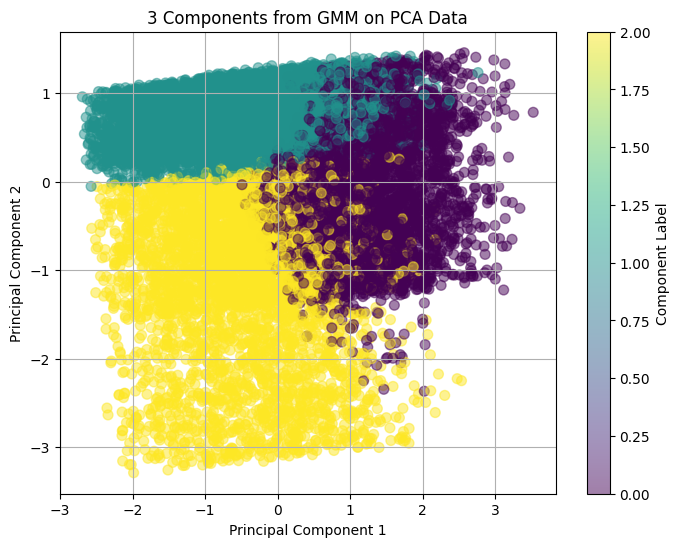

In [19]:
# Apply GMM with chosen number of clusters
n_components_gmm = 3 # TODO
gmm = GaussianMixture(n_components=n_components_gmm, random_state=42)
gmm_labels = gmm.fit_predict(X_std)

# Visualize the GMM clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, s=50, alpha=0.5, cmap='viridis')
plt.title(f'{n_components_gmm} Components from GMM on PCA Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Component Label')
plt.grid(True)
plt.show()

We'll also show you a 3d plot of the original, unscaled data with cluster labels using the plotly library.

In [20]:
import plotly.express as px

# Create a DataFrame for Plotly, including the cluster labels
plot_df = X_cleaned[features].copy()
plot_df['Cluster'] = gmm_labels # Add the cluster labels

# Create the 3D scatter plot using Plotly Express
fig = px.scatter_3d(plot_df,
                    x='age',
                    y='became_member_on',
                    z='income',
                    color='Cluster', # Color by the cluster labels
                    title='3D GMM Clusters on Original Data (Plotly)')

# Update layout for better readability
fig.update_layout(scene = dict(
                    xaxis_title='Age',
                    yaxis_title='Became Member On',
                    zaxis_title='Income'),
                    margin=dict(l=0, r=0, b=0, t=40))


fig.show()

4. (15 pts) **Comparing Clusters**

For every cluster $i$ found by k-means, find the average and standard deviation of the **original** (unscaled) features for all samples in cluster $i$. Display these values for every cluster.

Repeat this process for your GMM clusters.

In [36]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

print("Stats for K-means")
for i in range(4):
    mask = (kmeans_labels == i)
    cluster_points = X_cleaned[mask]

    stats = pd.DataFrame({
        "mean": cluster_points.mean(axis=0),
        "std":  cluster_points.std(axis=0),
    }, index=features)

    print(f"Cluster {i}")
    print(stats)
    print("\n\n")

# Calculate the average and standard deviation of all features for GMM clusters


print("Stats for GMM")
for i in range(3):
    mask = (gmm_labels == i)
    cluster_points = X_cleaned[mask]

    stats = pd.DataFrame({
        "mean": cluster_points.mean(axis=0),
        "std":  cluster_points.std(axis=0),
    }, index=features)

    print(f"Cluster {i}")
    print(stats)
    print("\n\n")

# TODO

Stats for K-means
Cluster 0
                     mean      std
age                 51.57    15.39
became_member_on 16546.57   306.53
income           58301.64 15167.89



Cluster 1
                     mean      std
age                 35.08     9.56
became_member_on 17431.25   216.17
income           52402.92 13367.75



Cluster 2
                     mean      std
age                 66.65    10.87
became_member_on 17445.91   210.84
income           54401.78 12929.07



Cluster 3
                     mean      std
age                 63.12    11.96
became_member_on 17238.80   295.21
income           91769.52 12608.75



Stats for GMM
Cluster 0
                     mean      std
age                 62.93    11.83
became_member_on 17174.49   299.65
income           90839.16 13569.47



Cluster 1
                     mean      std
age                 51.17    18.02
became_member_on 17530.63   111.93
income           55489.68 14470.71



Cluster 2
                     mean      std
age  

**Question:** Compare the clusters found by the two algorithms. Describe how you would characterize the clusters found by each algorithm. You can use the 3d plots on unscaled data, 2d plots on PCA data and/or the means/std deviations to inform your cluster descriptions.

**Answer:** K means favored grouping by age and income given the young, middle aged and older groups it identified. GMM found one group focused on age and income and the other two focused a little more on when the person became member.

5. (20 pts total) **Anomaly Detection**:
For this part of the assignment, we will be using data from the [NAB dataset](https://www.kaggle.com/datasets/boltzmannbrain/nab); specifically the ```ec2_request_latency_system_failure.csv``` dataset: CPU usage data from a server in Amazon's East Coast datacenter. The dataset ends with complete system failure resulting from a documented failure of AWS API servers. Your job in this section is to use the [```dbscan```](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) algorithm to detect the anomalies leading to the failure.

We'll read in the data and convert the timestamp to the ```df_ec2``` DataFrame index; you'll be clustering the ```value``` feature. Because this data only has one feature, you do not need to scale the data.


In [37]:
df_ec2 = pd.read_csv('/content/ec2_request_latency_system_failure.csv')

#Convert the timestamp feature to an index
df_ec2['timestamp'] = pd.to_datetime(df_ec2['timestamp'])
df_ec2 = df_ec2.set_index('timestamp')

display(df_ec2.head())
display(df_ec2.info())

,value
timestamp,
2014-03-07 03:41:00,45.87
2014-03-07 03:46:00,47.61
2014-03-07 03:51:00,42.58
2014-03-07 03:56:00,46.03
2014-03-07 04:01:00,44.99


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4032 entries, 2014-03-07 03:41:00 to 2014-03-21 03:41:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   4032 non-null   float64
dtypes: float64(1)
memory usage: 63.0 KB


None

5(a) (10 pts). For 1D data, setting ```min_samples``` to 3 is often a good starting point for DBSCAN. In this question, you'll use the [sklearn NearestNeighbors](https://scikit-learn.org/stable/modules/neighbors.html#neighbors) algorithm to create an elbow plot for setting the ```eps``` parameter.

To do so, follow these steps:



1.   Fit the NearestNeighbors model to the data. When instantiating NearestNeighbors, use only the ```n_neighbors``` parameter set to 3 (the ```min_samples``` setting).
2.   Find the k-nearest neighbors for each point. Example usage: ```distances, indices = neighbors.kneighbors(data)```. You will only use the ```distances``` return value for this test.
3. Sort the resulting distances using [```np.sort```](https://numpy.org/doc/stable/reference/generated/numpy.sort.html), and plot using matplotlib.plot().

To zoom in on the relevant section of the graph, we crop to the x-values (points sorted by distance to their k-th nearest neighbor) of 4000-4030 and the y-values (distance to the k-th nearest neighbor of 0,2.




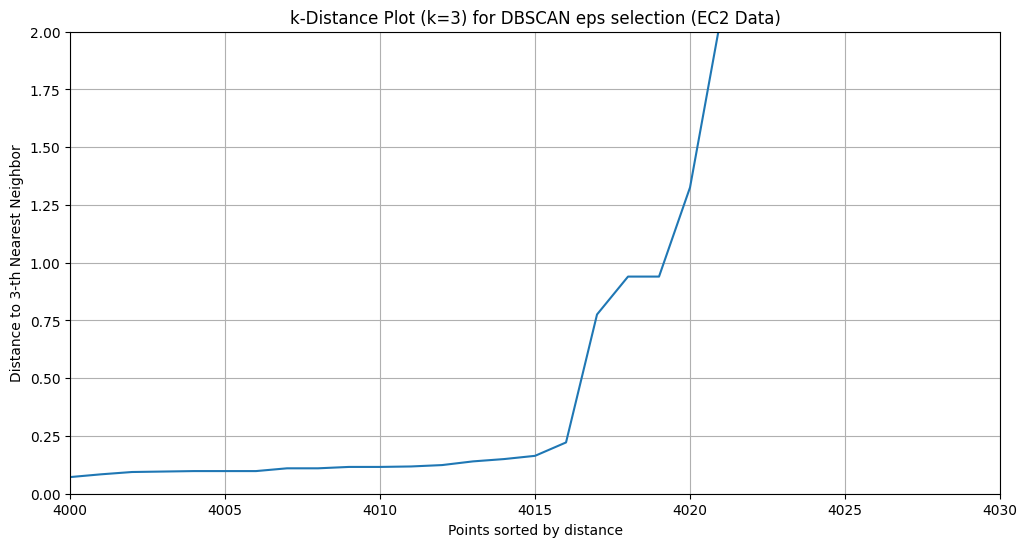

In [38]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Calculate the distance to the k-th nearest neighbor for each point
# For 1D data, a min_samples of 3 is often a good starting point for DBSCAN.
# So we'll use k=3 for the k-distance plot.
k = 3

# Fit a NearestNeighbors model to the data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(df_ec2)

# Find the k-nearest neighbors for each datapoint in df_ec2
distances, indices = neighbors.kneighbors(df_ec2) # TODO

# Sort the distances to the k-th nearest neighbor and save in variable k_distance_ec2
k_distance_ec2 = np.sort(distances[:, -1]) # TODO

# Plot the k-distance
plt.figure(figsize=(12, 6))
plt.plot(k_distance_ec2)
plt.title(f'k-Distance Plot (k={k}) for DBSCAN eps selection (EC2 Data)')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k}-th Nearest Neighbor')
plt.grid(True)

# Set the x-axis limits to the specified range
plt.xlim(4000, 4030)
plt.ylim(0,2)


plt.show()

As this elbow plot is not the cleanest, we'll suggest using ```eps=0.25``` as an approximate epsilon setting for DBSCAN on this problem.

5(b) (4 pts). Train [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) (from sklearn) on the data with ```eps=0.25, min_samples=3```. and predict labels for each datapoint. Save the labels in a variable named ```dbscan_labels```.

In [39]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.25, min_samples=3)

# Apply DBSCAN to the data
dbscan_labels = dbscan.fit_predict(df_ec2)

# Store the resulting cluster labels in a new column in the original df_temperature DataFrame.
df_ec2['dbscan_label'] = dbscan_labels

5(c) (6 pts). Get the counts of each unique cluster label in `dbscan_label` and print out each count. Then create a new dataframe, ```anomalies```, a filtered version of your original DataFrame that contains only the rows where the `dbscan_label` is -1 (anomalies).



In [42]:
# Get the counts of each unique cluster label
cluster_counts = df_ec2['dbscan_label'].value_counts()

# Filter the DataFrame to select only the rows with label -1 (anomalies)
anomalies = df_ec2[df_ec2['dbscan_label'] == -1].copy()

# Display the head of the anomalies DataFrame
display(anomalies.head())

print(f"# Anomalies: {len(anomalies)}")

,value,dbscan_label
timestamp,,
2014-03-14 09:06:00,30.48,-1
2014-03-14 18:46:00,36.89,-1
2014-03-18 22:21:00,54.51,-1
2014-03-18 22:36:00,65.68,-1
2014-03-18 22:41:00,99.25,-1


# Anomalies: 15


**Question:** How many anomalies did DBSCAN find?

**Answer:** 15

We will visualize the data and highlight the anomalies identified by the tuned DBSCAN.



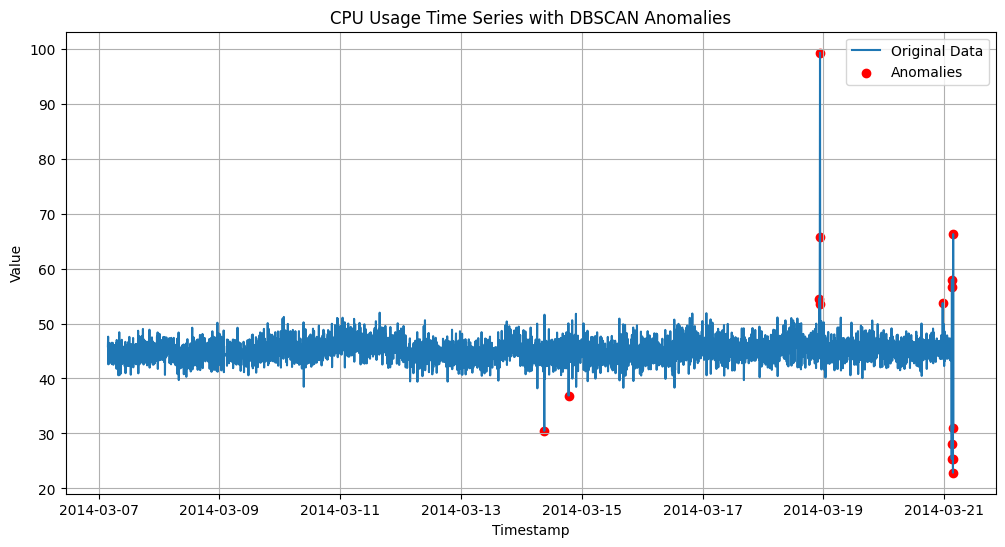

In [43]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the original time series data
ax.plot(df_ec2.index, df_ec2['value'], label='Original Data')

# Plot the anomalies (where dbscan_label_tuned is -1)
anomalies = df_ec2[df_ec2['dbscan_label'] == -1]
ax.scatter(anomalies.index, anomalies['value'], color='red', marker='o', label='Anomalies')

# Set the title and labels
ax.set_title('CPU Usage Time Series with DBSCAN Anomalies')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Value')

# Add a legend
ax.legend()

# Display the plot
plt.grid(True)
plt.show()

**Question:** Based on this anomaly graph, between which two dates would you have begun trying to diagnose a problem for this server?

**Answer:** I'd start between the 18th and 19th approximately, closer to the 19th. That's when an increase in CPU occurs. Without more context the transient decreases wouldn't be a real concern.